In [5]:
import numpy as np
from scipy.special import spherical_jn
from scipy.optimize import brentq

# ============================
# Physical constants
# ============================
kB = 1.380649e-23       # J/K
u = 1.66053906660e-27   # atomic mass unit [kg]
m_Ar = 39.948 * u       # argon atom/ion mass [kg]

# ============================
# Parameters
# ============================
T = 5000                # K
gamma = 5/3
R = 15e-3               # m

# Hydrogen plasma sound speed
c = np.sqrt(gamma * kB * T / m_Ar)

# ============================
# Derivative of spherical Bessel j_l
# rigid cavity condition: j_l'(alpha)=0
# ============================

def d_spherical_jn(l, x):
    return spherical_jn(l, x, derivative=True)
    # solution for the spherical equation using spherical_jn package

def find_roots_for_l(l, xmax, dx=0.01):
    roots = []
    x_values = np.arange(1e-6, xmax, dx)

    f_old = d_spherical_jn(l, x_values[0])
    x_old = x_values[0]

    for x in x_values[1:]:
        f_new = d_spherical_jn(l, x)

        if f_old * f_new < 0:
            root = brentq(lambda y: d_spherical_jn(l, y), x_old, x)
            roots.append(root)

        f_old = f_new
        x_old = x

    return roots

# ============================
# Second symmetric resonance mode: l=0, n=2
# ============================
l0_roots = find_roots_for_l(l=0, xmax=30)
alpha_limit = l0_roots[2]   # second l=0 resonance , l0_roots[limit : 1]

# ============================
# Find all modes below this limit
# ============================
modes = []

for l in range(0, 20):
    roots = find_roots_for_l(l, xmax=alpha_limit)

    for n, alpha in enumerate(roots, start=1):
        f = c * alpha / (2 * np.pi * R)

        modes.append({
            "l": l,
            "n": n,
            "alpha": alpha,
            "frequency_Hz": f,
            "degeneracy": 2*l + 1
        })

# Sort by frequency
modes = sorted(modes, key=lambda m: m["frequency_Hz"])

# ============================
# Display
# ============================
print(f"T = {T} K")
print(f"c = {c:.1f} m/s")
print(f"R = {R*1e3:.1f} mm")
print(f"Limit: second spherical mode l=0,n=2")
print(f"alpha_limit = {alpha_limit:.4f}\n")

print("Modes up to second symmetric resonance:")
print("------------------------------------------------------")

for i, m in enumerate(modes, start=1):
    print(
        f"{i:2d}. l={m['l']:2d}, n={m['n']:1d}, "
        f"alpha={m['alpha']:.4f}, "
        f"f={m['frequency_Hz']/1000:.2f} kHz, "
        f"degeneracy={m['degeneracy']}"
    )

T = 5000 K
c = 1317.0 m/s
R = 15.0 mm
Limit: second spherical mode l=0,n=2
alpha_limit = 10.9041

Modes up to second symmetric resonance:
------------------------------------------------------
 1. l= 1, n=1, alpha=2.0816, f=29.09 kHz, degeneracy=3
 2. l= 2, n=1, alpha=3.3421, f=46.70 kHz, degeneracy=5
 3. l= 0, n=1, alpha=4.4934, f=62.79 kHz, degeneracy=1
 4. l= 3, n=1, alpha=4.5141, f=63.08 kHz, degeneracy=7
 5. l= 4, n=1, alpha=5.6467, f=78.90 kHz, degeneracy=9
 6. l= 1, n=2, alpha=5.9404, f=83.01 kHz, degeneracy=3
 7. l= 5, n=1, alpha=6.7565, f=94.41 kHz, degeneracy=11
 8. l= 2, n=2, alpha=7.2899, f=101.87 kHz, degeneracy=5
 9. l= 0, n=2, alpha=7.7253, f=107.95 kHz, degeneracy=1
10. l= 6, n=1, alpha=7.8511, f=109.71 kHz, degeneracy=13
11. l= 3, n=2, alpha=8.5838, f=119.95 kHz, degeneracy=7
12. l= 7, n=1, alpha=8.9348, f=124.85 kHz, degeneracy=15
13. l= 1, n=3, alpha=9.2058, f=128.64 kHz, degeneracy=3
14. l= 4, n=2, alpha=9.8404, f=137.51 kHz, degeneracy=9
15. l= 8, n=1, alpha=10.010

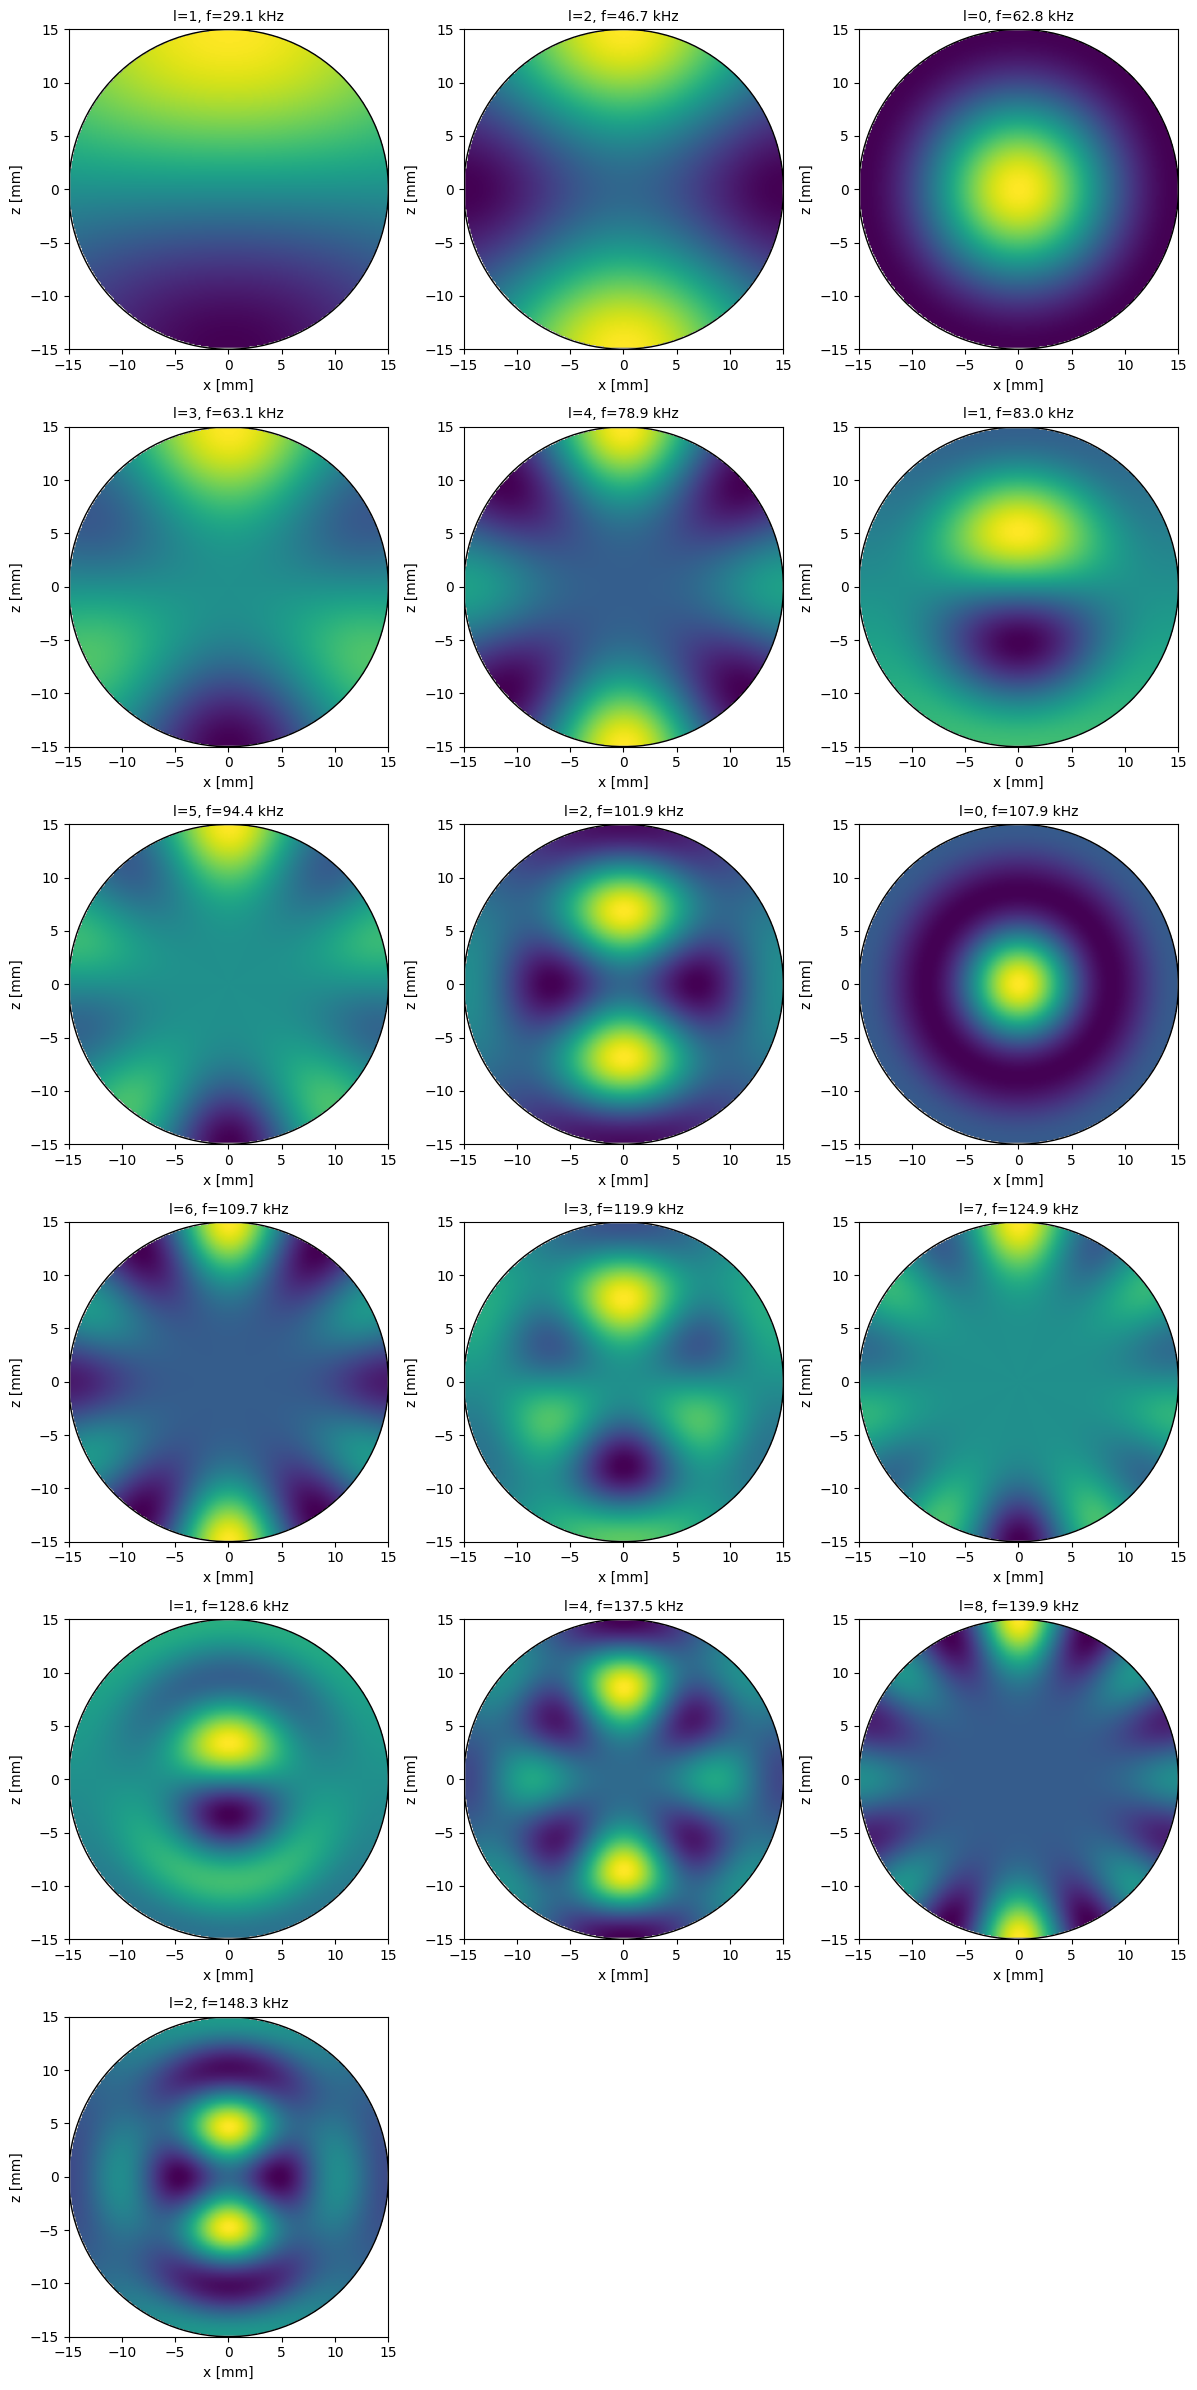

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, eval_legendre

def plot_modes_grid(modes, R, ncols=3):

    N = 250

    x = np.linspace(-R, R, N)
    z = np.linspace(-R, R, N)

    X, Z = np.meshgrid(x, z)

    r = np.sqrt(X**2 + Z**2)

    theta = np.arccos(
        np.divide(Z, r, out=np.zeros_like(r), where=r != 0)
    )

    inside = r <= R

    n_modes = len(modes)
    nrows = int(np.ceil(n_modes / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4*ncols, 4*nrows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, mode in zip(axes, modes):

        l = mode["l"]
        alpha = mode["alpha"]
        f = mode["frequency_Hz"]

        # Radial dependence
        radial = spherical_jn(l, alpha * r / R)

        # Angular dependence (m=0)
        angular = eval_legendre(l, np.cos(theta))

        pressure = radial * angular
        pressure[~inside] = np.nan

        im = ax.imshow(
            pressure,
            extent=[-R*1e3, R*1e3, -R*1e3, R*1e3],
            origin="lower",
            aspect="equal"
        )

        ax.set_title(
            f"l={l}, f={f/1000:.1f} kHz",
            fontsize=10
        )

        ax.set_xlabel("x [mm]")
        ax.set_ylabel("z [mm]")

        circle = plt.Circle(
            (0, 0),
            R*1e3,
            fill=False
        )

        ax.add_patch(circle)

    # Remove empty axes
    for ax in axes[len(modes):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Run
plot_modes_grid(modes, R, ncols=3)